# 03 — Modeling: predict `is_adopted` (Dogs & Cats, separately)

Two algorithms, one shared pipeline, compared head to head:
- **Logistic Regression** (regularized) — interpretable baseline
- **XGBoost** — main model

**Iron rules (decided in EDA, not changed here):**
1. Dogs and cats are modeled **separately** — 4 models (LR/XGB × Dog/Cat); never pooled.
2. **Leakage columns never used as features:** `outcome_type, outcome_subtype, outcome_date, length_of_stay_days, is_euthanasia`.

**Split = time-based (not random):** `intake_year` 2013–2022 → train, 2023–2025 → test. Adoption rate drifted ~42%→~66%, so a random split would leak the future and overstate performance. `intake_year` is used only to split, never as a feature. **2025 is a partial year** — read its test numbers with care.

**Leakage discipline:** every data-driven step (top-N breed/color thresholds, scaler stats, category sets) is **fit on train only**, then applied to test.

**Color experiment:** color was a weak EDA feature and is confounded with sex in cats (Tortie/Calico↔Female). So XGBoost is trained **with and without color** (per species) to measure color's real test contribution; LR stays fixed with color to limit model count. SHAP (computed on train) checks whether color adds anything **after controlling for sex**.

## 1. Setup

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, f1_score, precision_score, recall_score,
                             confusion_matrix, brier_score_loss)
from sklearn.calibration import calibration_curve
from xgboost import XGBClassifier
import shap

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('libraries loaded | xgboost + shap OK')

libraries loaded | xgboost + shap OK


## 2. Load, filter to dogs/cats, build `df_adopt` (rules 2–3)

In [34]:
# ====== EDIT THIS IF YOUR DATA LIVES ELSEWHERE ======
DATA_PATH = '../data/processed/df_full_merged.csv'
# ====================================================
df= pd.read_csv(DATA_PATH)
print('df:', df.shape)

TARGET = 'is_adopted'
# Rule 4: leakage columns — listed so they are never selected as features
LEAKAGE_COLS = ['outcome_type', 'outcome_subtype', 'outcome_date',
                'length_of_stay_days']
print('leakage (never used as features):', LEAKAGE_COLS)

df: (162765, 24)
leakage (never used as features): ['outcome_type', 'outcome_subtype', 'outcome_date', 'length_of_stay_days']


## 3. Deterministic feature derivation (no fitting — leakage-safe)

These transforms use **no learned parameters** (fixed bins, fixed maps, the EDA `to_color_group`), so applying them to the whole frame before the split introduces no leakage. Anything data-driven (top-N, scaling) is deferred to the train-only preprocessor in §6.

In [35]:
# --- color grouping: REUSE the EDA to_color_group logic verbatim (do not rewrite) ---
COLOR_BASE = {
    'Black': 'Black', 'White': 'White',
    'Brown': 'Brown', 'Chocolate': 'Brown', 'Sable': 'Brown', 'Liver': 'Brown',
    'Agouti': 'Brown', 'Ruddy': 'Brown',
    'Tan': 'Tan', 'Fawn': 'Tan', 'Buff': 'Tan', 'Apricot': 'Tan', 'Gold': 'Tan', 'Yellow': 'Tan',
    'Blue': 'Blue/Gray', 'Gray': 'Blue/Gray', 'Silver': 'Blue/Gray', 'Lilac': 'Blue/Gray',
    'Red': 'Red/Orange', 'Orange': 'Red/Orange',
    'Cream': 'Cream',
}
def to_color_group(c):
    if pd.isna(c):                                          return 'Unknown'
    if 'Tabby' in c:                                        return 'Tabby'
    if 'Calico' in c:                                       return 'Calico'
    if 'Tortie' in c or 'Torbie' in c:                      return 'Tortie'
    if 'Point' in c:                                        return 'Point'
    if 'Brindle' in c:                                      return 'Brindle'
    if 'Merle' in c:                                        return 'Merle'
    if 'Tricolor' in c:                                     return 'Tricolor'
    return COLOR_BASE.get(c.split()[0], 'Other')

df['color_group'] = df['primary_color'].map(to_color_group)
# secondary: missing = single color (no imputation)
df['secondary_color_group'] = df['secondary_color'].map(to_color_group).replace('Unknown', 'single color')
# EDA decision: fold cats' sparse warm colors into 'Other'; dogs keep them
CAT_MERGE_TO_OTHER = ['Tan', 'Cream', 'Brown', 'Red/Orange', 'Tricolor', 'Brindle', 'Merle']
_is_cat = df['animal_type'].eq('Cat')
df.loc[_is_cat & df['color_group'].isin(CAT_MERGE_TO_OTHER), 'color_group'] = 'Other'

# --- age_bucket for LR (NaN age -> its own 'Unknown' bucket) ---
AGE_BINS   = [0, 60, 180, 365, 730, 1825, 3650, 5475, np.inf]
AGE_LABELS = ['<2mo', '2-6mo', '6-12mo', '1-2yr', '2-5yr', '5-10yr', '10-15yr', '15yr+']
df['age_bucket'] = pd.cut(df['age_at_intake_days'], bins=AGE_BINS, labels=AGE_LABELS,
                          right=False).astype('object').fillna('Unknown')

# --- is_sn (legal feature: recorded at intake). Unknown sex -> NaN -> explicit category for LR ---
df['is_sn_cat'] = df['is_previously_spayed_neutered'].map({1.0: 'sn_yes', 0.0: 'sn_no'}).fillna('sn_unknown')

# --- intake_month cyclical encoding for LR (Dec and Jan are neighbors) ---
df['month_sin'] = np.sin(2 * np.pi * df['intake_month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['intake_month'] / 12)

# --- intake_health_condition: keep the well-populated levels, merge the rest into 'Other' ---
# (this folds the spec's small categories Medical/Aged/Other, plus other tiny ones, into 'Other')
HEALTH_KEEP = ['Normal', 'Injured', 'Sick', 'Nursing', 'Neonatal']
_before = df['intake_health_condition'].value_counts().to_dict()
df['intake_health_condition'] = df['intake_health_condition'].where(
    df['intake_health_condition'].isin(HEALTH_KEEP), 'Other')
# fill any stray NaN in OHE categorical inputs so encoders never choke
for c in ['sex', 'intake_reason']:
    df[c] = df[c].fillna('Missing')

print('health_condition merged ->', df['intake_health_condition'].value_counts().to_dict())
print('  (merged out of:', {k: v for k, v in _before.items() if k not in HEALTH_KEEP}, ')')
print('cat color_group ->', df.loc[_is_cat, 'color_group'].value_counts().to_dict())

health_condition merged -> {'Normal': 139975, 'Injured': 9214, 'Sick': 6004, 'Nursing': 3721, 'Other': 1969, 'Neonatal': 1882}
  (merged out of: {'Medical': 577, 'Aged': 522, 'Other': 337, 'Pregnant': 150, 'Feral': 143, 'Behavior': 80, 'Med Attn': 78, 'Unknown': 29, 'Med Urgent': 21, 'Neurologic': 11, 'Parvo': 11, 'Space': 4, 'Agonal': 4, 'Panleuk': 1, 'Congenital': 1} )
cat color_group -> {'Tabby': 31173, 'Black': 15572, 'Tortie': 6192, 'Blue/Gray': 4891, 'White': 4008, 'Calico': 3335, 'Point': 2670, 'Other': 962}


## 4. Time-based split (rule: 2013–2022 train, 2023–2025 test)

In [36]:
train = df[df['intake_year'] <= 2022].copy()
test  = df[df['intake_year'] >= 2023].copy()
print(f'TRAIN {len(train):,}   TEST {len(test):,}   (lost 0 rows — split is exhaustive)')
for nm, fr in [('TRAIN', train), ('TEST', test)]:
    rates = {k: round(v, 3) for k, v in fr.groupby('animal_type')[TARGET].mean().items()}
    print(f'  {nm}: {fr["animal_type"].value_counts().to_dict()} | adopt rate {rates}')
print('NOTE: 2025 is a PARTIAL year; its share of test is incomplete — interpret test cautiously.')

# per-species frames. intake_year is kept INSIDE the frames only for the inner time-split (xgb tuning);
# it is never listed in any transformer, so it is never a feature.
TR = {sp: train[train.animal_type == sp].copy() for sp in ['Dog', 'Cat']}
TE = {sp: test[test.animal_type == sp].copy()  for sp in ['Dog', 'Cat']}
for sp in ['Dog', 'Cat']:
    print(f'  {sp}: train {len(TR[sp]):,}  test {len(TE[sp]):,}')

TRAIN 138,279   TEST 24,486   (lost 0 rows — split is exhaustive)
  TRAIN: {'Dog': 82389, 'Cat': 55890} | adopt rate {'Cat': 0.492, 'Dog': 0.494}
  TEST: {'Cat': 12913, 'Dog': 11573} | adopt rate {'Cat': 0.627, 'Dog': 0.641}
NOTE: 2025 is a PARTIAL year; its share of test is incomplete — interpret test cautiously.
  Dog: train 82,389  test 11,573
  Cat: train 55,890  test 12,913


## 5. Cat-breed decision (data-driven, computed on TRAIN only)

In [37]:
ct = TR['Cat']
g = ct.groupby('primary_breed')[TARGET].agg(rate='mean', n='count')
g = g[g['n'] >= 100].sort_values('n', ascending=False)
print('CAT breed adoption rate (TRAIN, n>=100):')
print(g.round(3).to_string())
spread = g['rate'].max() - g['rate'].min()
print(f'\nspread (max-min) = {spread:.3f}')

CAT_USE_BREED = bool(spread >= 0.05)
CAT_BREED_TOPN = 4   # Domestic Shorthair, Domestic Medium Hair, Domestic Longhair, Siamese (~98%)
if CAT_USE_BREED:
    cov = ct['primary_breed'].isin(
        ['Domestic Shorthair', 'Domestic Medium Hair', 'Domestic Longhair', 'Siamese']).mean()
    print(f'DECISION: cat breeds DIFFER (spread {spread:.3f} >= 0.05) -> '
          f'use top-{CAT_BREED_TOPN} breeds + Other for cats (top-4 covers {cov:.1%}). '
          f'is_mix ~= "is it DSH" for cats, so explicit breed is more informative.')
else:
    print('DECISION: cat breeds similar -> use is_mix only, no breed for cats.')

DOG_BREED_TOPN = 20
BREED_TOPN = {'Dog': DOG_BREED_TOPN, 'Cat': CAT_BREED_TOPN}
USE_BREED  = {'Dog': True,           'Cat': CAT_USE_BREED}
print('USE_BREED =', USE_BREED, '| BREED_TOPN =', BREED_TOPN)

CAT breed adoption rate (TRAIN, n>=100):
                       rate      n
primary_breed                     
Domestic Shorthair    0.486  46048
Domestic Medium Hair  0.522   4604
Domestic Longhair     0.528   2147
Siamese               0.518   1784
American Shorthair    0.383    264
Snowshoe              0.582    244
Maine Coon            0.601    158
Manx                  0.540    137
Russian Blue          0.536    110

spread (max-min) = 0.219
DECISION: cat breeds DIFFER (spread 0.219 >= 0.05) -> use top-4 breeds + Other for cats (top-4 covers 97.7%). is_mix ~= "is it DSH" for cats, so explicit breed is more informative.
USE_BREED = {'Dog': True, 'Cat': True} | BREED_TOPN = {'Dog': 20, 'Cat': 4}


## 6. Shared preprocessing — encoding layer splits by algorithm

Same feature *content* for both algorithms; only the **encoding** differs:

| feature | LR | XGBoost |
|---|---|---|
| age_at_intake_days | `age_bucket` one-hot (Unknown bucket) | raw continuous (NaN native) |
| intake_month | sin/cos | raw int 1–12 |
| is_sn | 3-level one-hot (yes/no/unknown) | raw 0/1, NaN native |
| sex, intake_reason, intake_health_condition, color_group, secondary_color_group | one-hot | one-hot |
| primary_breed | top-N + Other (one-hot, **fit on train**) | top-N + Other |
| is_mix | passthrough 0/1 | passthrough 0/1 |
| numeric (month sin/cos) | StandardScaler (**fit on train**) | — |

`OneHotEncoder(handle_unknown=...)` and `StandardScaler` are fit only inside `.fit(X_train)`; the top-N grouping uses the encoder's infrequent-category mechanism, also train-fitted.

In [38]:
def make_preprocessor(algo, sp, include_color):
    ohe_cols = ['sex', 'intake_reason', 'intake_health_condition']
    if include_color:
        ohe_cols += ['color_group', 'secondary_color_group']
    if algo == 'lr':
        ohe_cols += ['is_sn_cat', 'age_bucket']

    transformers = [('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ohe_cols)]

    if USE_BREED[sp]:
        # top-N most frequent breeds + one 'infrequent' (=Other); unseen test breeds -> infrequent
        transformers.append(('breed',
            OneHotEncoder(handle_unknown='infrequent_if_exist',
                          max_categories=BREED_TOPN[sp] + 1, sparse_output=False),
            ['primary_breed']))

    if algo == 'lr':
        transformers.append(('scale', StandardScaler(), ['month_sin', 'month_cos']))
        transformers.append(('mix', 'passthrough', ['is_mix']))
    else:  # xgb: keep numeric raw (XGB handles NaN), month as int
        transformers.append(('num', 'passthrough',
            ['age_at_intake_days', 'intake_month', 'is_mix', 'is_previously_spayed_neutered']))

    return ColumnTransformer(transformers, remainder='drop')

# quick sanity: feature count per config
for sp in ['Dog', 'Cat']:
    for algo in ['lr', 'xgb']:
        p = make_preprocessor(algo, sp, include_color=True)
        ncol = p.fit_transform(TR[sp]).shape[1]
        print(f'{sp} {algo}: {ncol} features (with color)')

Dog lr: 76 features (with color)
Dog xgb: 65 features (with color)
Cat lr: 56 features (with color)
Cat xgb: 45 features (with color)


## 7. Train models & evaluate on the held-out future (test)

In [39]:
def evaluate(model_tag, sp, y_true, proba, thr=0.5):
    pred = (proba >= thr).astype(int)
    return dict(model=model_tag, species=sp,
                AUC=roc_auc_score(y_true, proba),
                precision=precision_score(y_true, pred),
                recall=recall_score(y_true, pred),
                F1=f1_score(y_true, pred),
                Brier=brier_score_loss(y_true, proba),
                n_test=len(y_true))

RESULTS = []
PRED_STORE = {}   # (species, tag) -> (y_true, proba)
LR_MODELS = {}    # species -> fitted Pipeline
XGB_MODELS = {}   # (species, tag) -> (preprocessor, fitted booster)

In [40]:
# ---------------- Logistic Regression (fixed: with color) ----------------
for sp in ['Dog', 'Cat']:
    Xtr, ytr = TR[sp], TR[sp][TARGET]
    Xte, yte = TE[sp], TE[sp][TARGET]
    pipe = Pipeline([('pre', make_preprocessor('lr', sp, include_color=True)),
                     ('clf', LogisticRegression(max_iter=2000, C=1.0))])  # L2-regularized
    pipe.fit(Xtr, ytr)                       # encoders/scaler fit on TRAIN only
    proba = pipe.predict_proba(Xte)[:, 1]
    tag = 'LR (color)'
    RESULTS.append(evaluate(tag, sp, yte.values, proba))
    PRED_STORE[(sp, tag)] = (yte.values, proba)
    LR_MODELS[sp] = pipe
    print(f'{sp} {tag}: AUC {RESULTS[-1]["AUC"]:.3f}  F1 {RESULTS[-1]["F1"]:.3f}  '
          f'Brier {RESULTS[-1]["Brier"]:.3f}')

Dog LR (color): AUC 0.735  F1 0.736  Brier 0.214
Cat LR (color): AUC 0.768  F1 0.751  Brier 0.190


In [41]:
# ---------------- XGBoost (with/without color) + time-aware inner tuning ----------------
def tune_and_fit_xgb(sp, include_color):
    full = TR[sp]
    # inner time-aware validation: train on <=2020, validate on 2021-2022 (NEVER touches test)
    inner_tr  = full[full.intake_year <= 2020]
    inner_val = full[full.intake_year.isin([2021, 2022])]
    pre = make_preprocessor('xgb', sp, include_color)
    Ztr  = pre.fit_transform(inner_tr)        # fit on inner-train only
    Zval = pre.transform(inner_val)
    best = None
    for depth in [3, 5]:
        for lr in [0.03, 0.1]:
            m = XGBClassifier(n_estimators=800, max_depth=depth, learning_rate=lr,
                              subsample=0.9, colsample_bytree=0.9, eval_metric='auc',
                              early_stopping_rounds=30, tree_method='hist',
                              n_jobs=4, random_state=RANDOM_STATE)
            m.fit(Ztr, inner_tr[TARGET], eval_set=[(Zval, inner_val[TARGET])], verbose=False)
            if best is None or m.best_score > best['score']:
                best = dict(score=float(m.best_score), depth=depth, lr=lr,
                            n=int(m.best_iteration) + 1)
    # refit on FULL train with chosen params (fresh preprocessor fit on full train)
    pre2 = make_preprocessor('xgb', sp, include_color)
    Ztr_full = pre2.fit_transform(full)
    final = XGBClassifier(n_estimators=best['n'], max_depth=best['depth'],
                          learning_rate=best['lr'], subsample=0.9, colsample_bytree=0.9,
                          eval_metric='auc', tree_method='hist', n_jobs=4,
                          random_state=RANDOM_STATE)
    final.fit(Ztr_full, full[TARGET])
    return pre2, final, best

for include_color in [True, False]:
    tag = 'XGB (color)' if include_color else 'XGB (no color)'
    for sp in ['Dog', 'Cat']:
        pre, final, best = tune_and_fit_xgb(sp, include_color)
        proba = final.predict_proba(pre.transform(TE[sp]))[:, 1]
        yte = TE[sp][TARGET].values
        RESULTS.append(evaluate(tag, sp, yte, proba))
        PRED_STORE[(sp, tag)] = (yte, proba)
        XGB_MODELS[(sp, tag)] = (pre, final)
        print(f'{sp} {tag}: best={best} | test AUC {RESULTS[-1]["AUC"]:.3f}  '
              f'F1 {RESULTS[-1]["F1"]:.3f}  Brier {RESULTS[-1]["Brier"]:.3f}')

Dog XGB (color): best={'score': 0.7072330045402395, 'depth': 5, 'lr': 0.1, 'n': 79} | test AUC 0.761  F1 0.748  Brier 0.205
Cat XGB (color): best={'score': 0.8102983269111524, 'depth': 5, 'lr': 0.1, 'n': 54} | test AUC 0.814  F1 0.767  Brier 0.174
Dog XGB (no color): best={'score': 0.7043868993803313, 'depth': 5, 'lr': 0.03, 'n': 221} | test AUC 0.761  F1 0.754  Brier 0.205
Cat XGB (no color): best={'score': 0.8101668382939144, 'depth': 5, 'lr': 0.1, 'n': 42} | test AUC 0.815  F1 0.764  Brier 0.175


## 8. Side-by-side comparison (LR vs XGB · Dog vs Cat · with/without color)

In [42]:
res = pd.DataFrame(RESULTS)
res = res[['species', 'model', 'AUC', 'precision', 'recall', 'F1', 'Brier', 'n_test']]
res_sorted = res.sort_values(['species', 'model']).round(3)
print(res_sorted.to_string(index=False))
print('\nAUC pivot:')
print(res.pivot_table(index='species', columns='model', values='AUC').round(3).to_string())

print('\nColor contribution (XGB test AUC, with - without):')
for sp in ['Dog', 'Cat']:
    a = res[(res.species == sp) & (res.model == 'XGB (color)')]['AUC'].iloc[0]
    b = res[(res.species == sp) & (res.model == 'XGB (no color)')]['AUC'].iloc[0]
    print(f'  {sp}: with {a:.3f}  vs  without {b:.3f}  -> delta {a-b:+.3f}')

species          model   AUC  precision  recall    F1  Brier  n_test
    Cat     LR (color) 0.768      0.776   0.727 0.751  0.190   12913
    Cat    XGB (color) 0.814      0.830   0.712 0.767  0.174   12913
    Cat XGB (no color) 0.815      0.831   0.706 0.764  0.175   12913
    Dog     LR (color) 0.735      0.789   0.690 0.736  0.214   11573
    Dog    XGB (color) 0.761      0.802   0.700 0.748  0.205   11573
    Dog XGB (no color) 0.761      0.801   0.712 0.754  0.205   11573

AUC pivot:
model    LR (color)  XGB (color)  XGB (no color)
species                                         
Cat           0.768        0.814           0.815
Dog           0.735        0.761           0.761

Color contribution (XGB test AUC, with - without):
  Dog: with 0.761  vs  without 0.761  -> delta +0.001
  Cat: with 0.814  vs  without 0.815  -> delta -0.001


### 8.1 Confusion matrices (threshold 0.5)

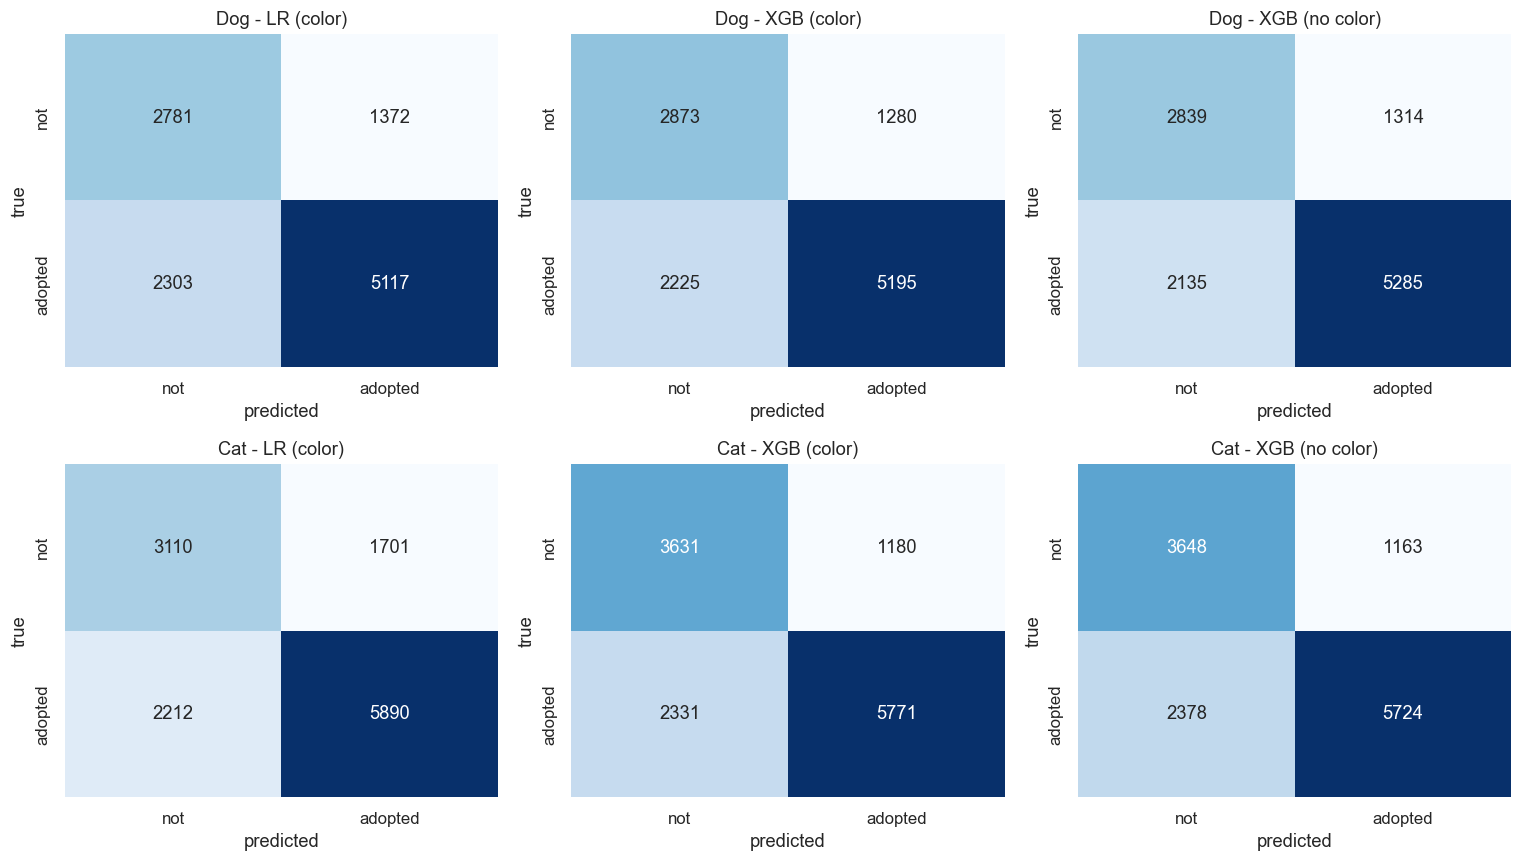

In [43]:
order = [('Dog', 'LR (color)'), ('Dog', 'XGB (color)'), ('Dog', 'XGB (no color)'),
         ('Cat', 'LR (color)'), ('Cat', 'XGB (color)'), ('Cat', 'XGB (no color)')]
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, (sp, tag) in zip(axes.ravel(), order):
    y, proba = PRED_STORE[(sp, tag)]
    cm = confusion_matrix(y, (proba >= 0.5).astype(int))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['not', 'adopted'], yticklabels=['not', 'adopted'])
    ax.set_title(f'{sp} - {tag}'); ax.set_xlabel('predicted'); ax.set_ylabel('true')
fig.tight_layout(); plt.show()

### 8.2 Calibration (reliability) — essential given the time drift; AUC alone is not enough

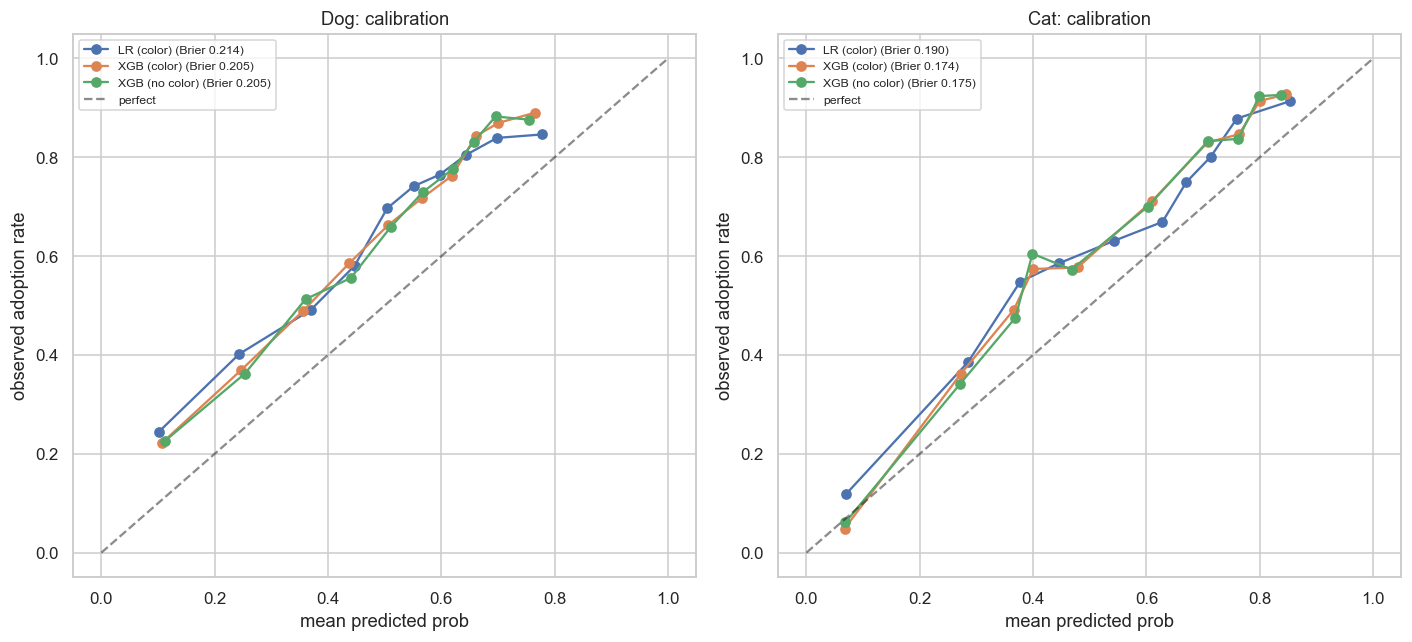

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, sp in zip(axes, ['Dog', 'Cat']):
    for tag in ['LR (color)', 'XGB (color)', 'XGB (no color)']:
        y, proba = PRED_STORE[(sp, tag)]
        frac, mean = calibration_curve(y, proba, n_bins=10, strategy='quantile')
        ax.plot(mean, frac, marker='o', label=f'{tag} (Brier {brier_score_loss(y, proba):.3f})')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='perfect')
    ax.set_title(f'{sp}: calibration'); ax.set_xlabel('mean predicted prob')
    ax.set_ylabel('observed adoption rate'); ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

## 9. Interpretability — what really drives adoption (after controlling for other features)?

### 9.1 LR coefficients (log-odds; red = lowers, green = raises adoption odds)

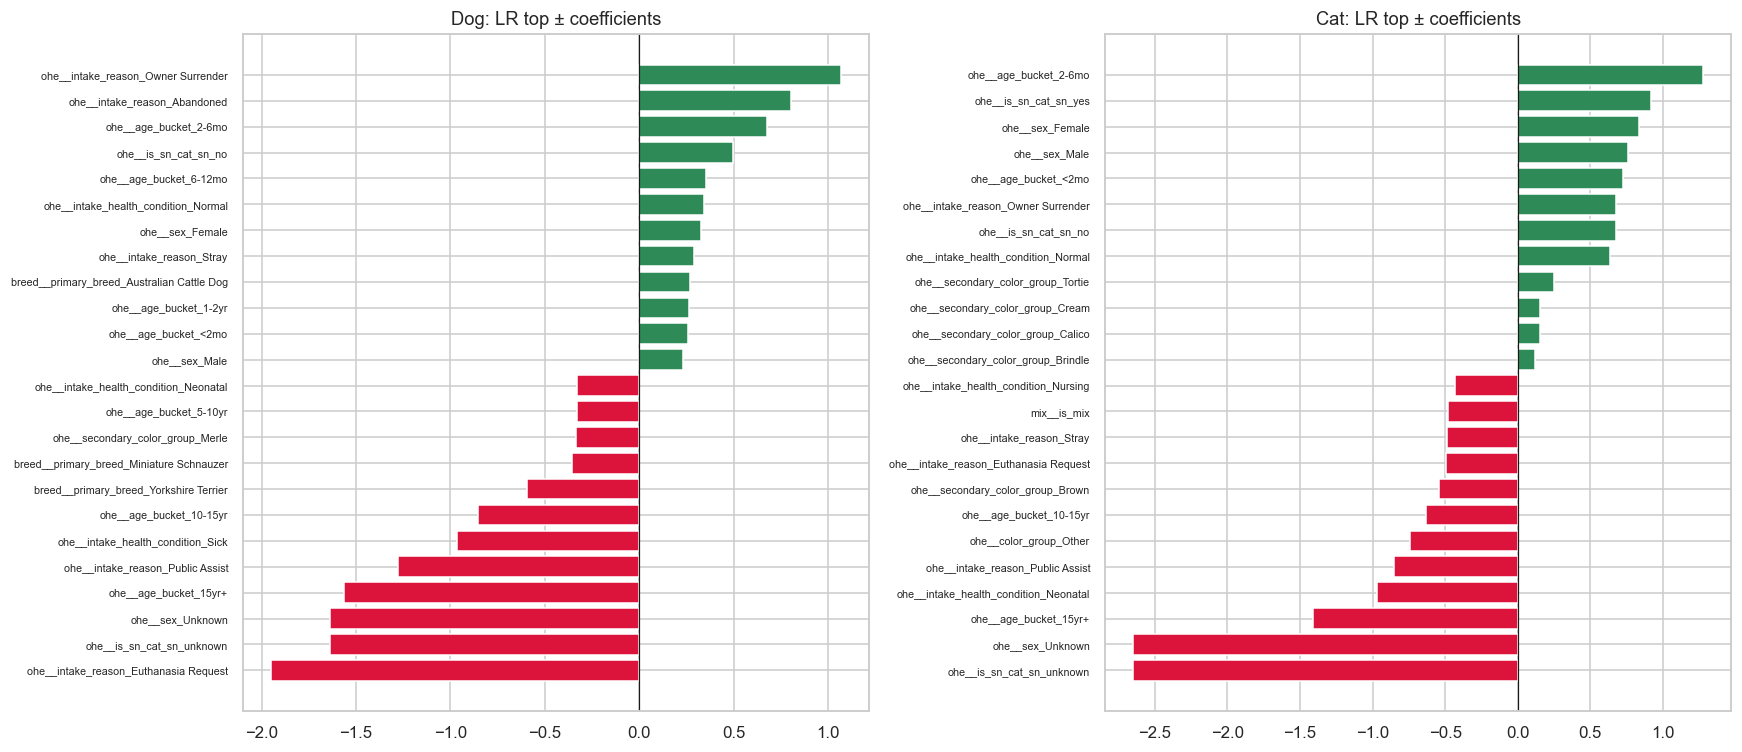

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, sp in zip(axes, ['Dog', 'Cat']):
    pipe = LR_MODELS[sp]
    names = pipe.named_steps['pre'].get_feature_names_out()
    s = pd.Series(pipe.named_steps['clf'].coef_[0], index=names).sort_values()
    top = pd.concat([s.head(12), s.tail(12)])
    ax.barh(range(len(top)), top.values,
            color=['crimson' if v < 0 else 'seagreen' for v in top.values])
    ax.set_yticks(range(len(top))); ax.set_yticklabels(top.index, fontsize=7)
    ax.axvline(0, color='k', lw=0.8); ax.set_title(f'{sp}: LR top ± coefficients')
fig.tight_layout(); plt.show()

### 9.2 XGBoost SHAP (computed on TRAIN; not impurity importance, which is biased for high-cardinality)

/var/folders/xv/__dg3mss3f1d57y41qhwz0dh0000gn/T/ipykernel_28883/3191921761.py:10: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, Z, feature_names=names, max_display=15, show=False)


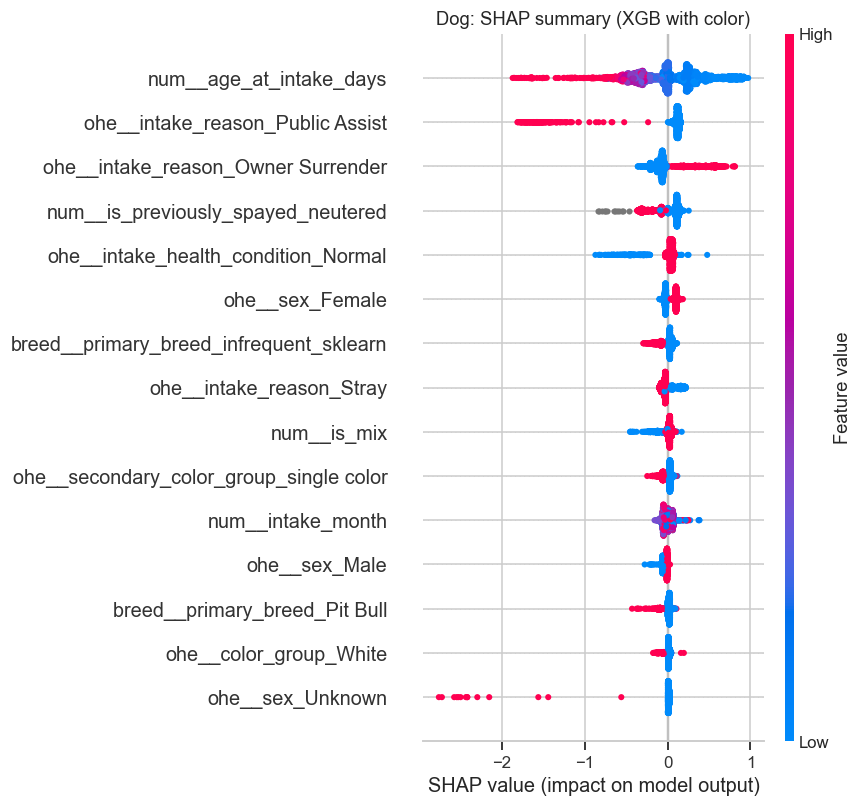

/var/folders/xv/__dg3mss3f1d57y41qhwz0dh0000gn/T/ipykernel_28883/3191921761.py:10: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, Z, feature_names=names, max_display=15, show=False)


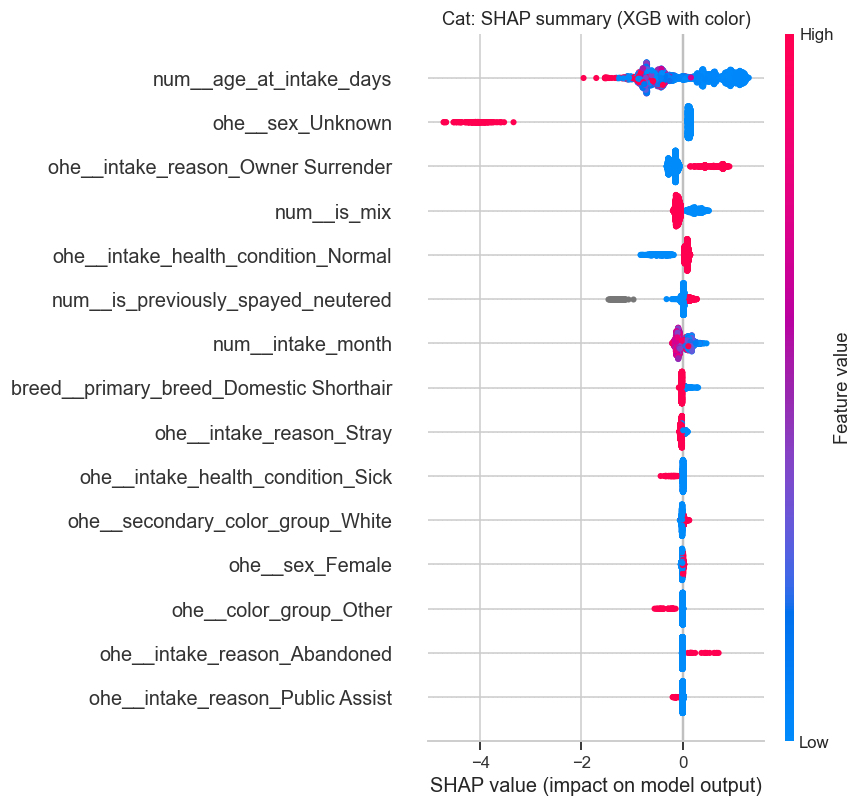

In [46]:
SHAP_INFO = {}
for sp in ['Dog', 'Cat']:
    pre, final = XGB_MODELS[(sp, 'XGB (color)')]
    names = list(pre.get_feature_names_out())
    samp = TR[sp].sample(min(2500, len(TR[sp])), random_state=RANDOM_STATE)
    Z = pre.transform(samp)
    sv = shap.TreeExplainer(final).shap_values(Z)
    SHAP_INFO[sp] = (names, np.abs(sv).mean(0))
    plt.figure()
    shap.summary_plot(sv, Z, feature_names=names, max_display=15, show=False)
    plt.title(f'{sp}: SHAP summary (XGB with color)'); plt.tight_layout(); plt.show()

### 9.3 Core question — does color add anything *after* controlling for sex?

In [47]:
rows = []
for sp in ['Dog', 'Cat']:
    names, msv = SHAP_INFO[sp]
    imp = pd.Series(msv, index=names)
    color_imp = imp[[n for n in names if n.startswith('ohe__color_group')
                     or n.startswith('ohe__secondary_color_group')]].sum()
    sex_imp = imp[[n for n in names if n.startswith('ohe__sex')]].sum()
    rows.append(dict(species=sp, color_mean_abs_shap=color_imp, sex_mean_abs_shap=sex_imp,
                     color_over_sex=color_imp / sex_imp if sex_imp else np.nan))
print(pd.DataFrame(rows).round(4).to_string(index=False))
print('\nExpectation from EDA: dog color ~ 0; cat color smaller than sex (much of the apparent')
print('color signal in cats is the Tortie/Calico<->Female confound being absorbed by sex).')

species  color_mean_abs_shap  sex_mean_abs_shap  color_over_sex
    Dog               0.1027             0.1153          0.8904
    Cat               0.0456             0.4169          0.1093

Expectation from EDA: dog color ~ 0; cat color smaller than sex (much of the apparent
color signal in cats is the Tortie/Calico<->Female confound being absorbed by sex).


## 10. Summary (fill-in-the-blank)

### Performance
- Best model per species (by test AUC + calibration): dogs → ____ , cats → ____ .
- LR vs XGBoost gap: ____ (is the extra complexity worth it?).
- Calibration: which model's predicted probabilities are trustworthy on the 2023–2025 future? ____ . Reminder: **2025 is partial**.

### Color experiment (XGBoost, with vs without color)
- Dog Δ AUC = ____ ; Cat Δ AUC = ____ . Keep color for: ____ .
- After controlling for sex (SHAP §9.3): cat color independent contribution = ____ ; dog ≈ ____ .

### What drives adoption (per species)
- **Dogs:** top features ____ , ____ , ____ (direction).
- **Cats:** top features ____ , ____ , ____ (direction).
- Does age push opposite directions across species, as EDA predicted? ____ .

### Caveats / next steps
- Time drift is real → prefer the better-calibrated model; consider recalibration / periodic retraining.
- `is_sn` × age collinearity (cat 0.58 / dog 0.41) distorts LR coefficient reading, not prediction.
- Threshold (0.5) can be tuned to the shelter's precision/recall preference.